In [1]:
# 导入项目所需的主要工具
# Import the main libraries required for the project
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
import math

# 如果 CUDA 可用就使用 GPU，否则自动使用 CPU
# Use the GPU when CUDA is available; otherwise use the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", device)

# 显示当前 GPU 名称，方便 Demo 时证明代码确实连接了 GPU
# Display the GPU name as evidence that the notebook is using CUDA
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
Device: cuda
GPU name: Tesla T4


# COMP3710 Lab 1 — Sierpiński Carpet

This notebook implements and analyses a GPU-accelerated Sierpiński Carpet using vectorised PyTorch tensor operations.

## Project Goals

- Generate the Sierpiński Carpet using a pixel-grid and ternary-coordinate algorithm.
- Process all image coordinates in parallel using PyTorch.
- Compare different recursion depths.
- Create multiple colour visualisations.
- Estimate the box-counting dimension.
- Compare the estimated dimension with the theoretical value.
- Compare CPU and GPU execution times.

Recursion depth: 5
Image size: (243, 243)
Occupied pixels: 32768
Expected occupied pixels: 32768
Tensor device: cuda:0


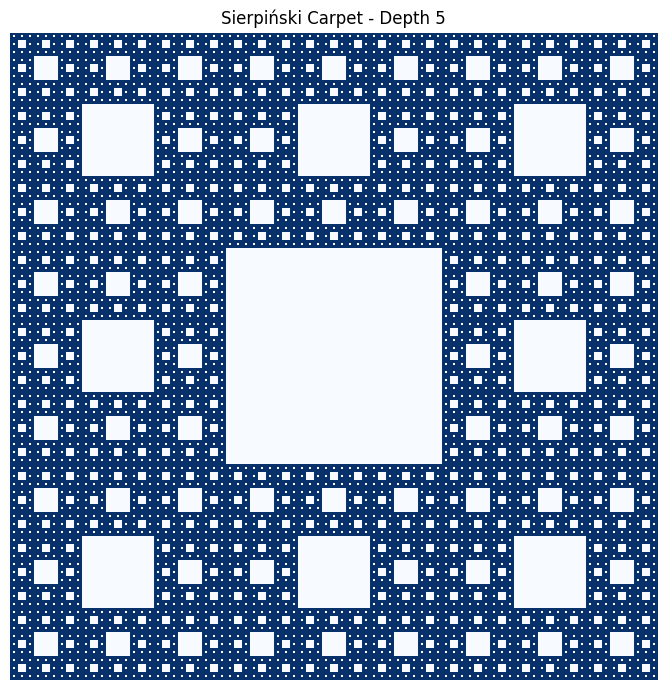

In [2]:
# 生成 Sierpiński Carpet
# Generate a Sierpiński Carpet
def generate_sierpinski_carpet(depth, target_device):
    """
    Generate a Sierpiński Carpet using ternary-coordinate testing.

    depth: recursion depth
    target_device: CPU or GPU device
    """

    # 深度 d 对应的图像边长为 3^d
    # At depth d, the image width and height are 3^d
    size = 3 ** depth

    # 在指定设备上创建所有横纵坐标
    # Create all horizontal and vertical coordinates on the selected device
    coordinates = torch.arange(
        size,
        device=target_device,
        dtype=torch.int64
    )

    y, x = torch.meshgrid(
        coordinates,
        coordinates,
        indexing="ij"
    )

    # True 表示保留该像素，False 表示删除该像素
    # True means the pixel remains; False means it is removed
    carpet = torch.ones(
        (size, size),
        dtype=torch.bool,
        device=target_device
    )

    # 创建坐标副本，用于逐层检查三进制数字
    # Copy the coordinates for checking ternary digits at each level
    check_x = x.clone()
    check_y = y.clone()

    # 这里只循环递归层数，不逐个循环处理像素
    # This loop processes recursion levels, not individual pixels
    for level in range(depth):

        # 如果 x 和 y 当前的三进制位都等于 1，
        # 该像素位于某一层的中央正方形中，需要删除
        # If the current ternary digits of both x and y equal 1,
        # the pixel is inside a centre square and must be removed
        centre_square = (
            (check_x % 3 == 1) &
            (check_y % 3 == 1)
        )

        carpet = carpet & (~centre_square)

        # 删除已经检查过的最低三进制位
        # Remove the ternary digit that has already been checked
        check_x = check_x // 3
        check_y = check_y // 3

    return carpet


# 使用深度 5 生成分形
# Generate the fractal at recursion depth 5
depth = 5
carpet = generate_sierpinski_carpet(depth, device)

# 计算并验证保留像素的数量
# Count and verify the number of remaining pixels
occupied_pixels = int(carpet.sum().item())
expected_pixels = 8 ** depth

print("Recursion depth:", depth)
print("Image size:", tuple(carpet.shape))
print("Occupied pixels:", occupied_pixels)
print("Expected occupied pixels:", expected_pixels)
print("Tensor device:", carpet.device)

# 将结果移回 CPU，以便 Matplotlib 绘图
# Move the result to the CPU for Matplotlib
carpet_image = carpet.cpu().numpy()

plt.figure(figsize=(7, 7))
plt.imshow(
    carpet_image,
    cmap="Blues",
    origin="upper",
    interpolation="nearest"
)
plt.title(f"Sierpiński Carpet - Depth {depth}")
plt.axis("off")
plt.tight_layout()
plt.show()

## Comparison of Different Recursion Depths

This section compares the Sierpiński Carpet at recursion depths 1 to 5.

At each recursion level, every retained square is divided into a 3 × 3 grid. The centre square is removed, while the other eight squares remain. Therefore, the number of occupied pixels at depth d is:

Occupied pixels = 8^d

The comparison demonstrates how the self-similar structure becomes increasingly detailed as the recursion depth increases.

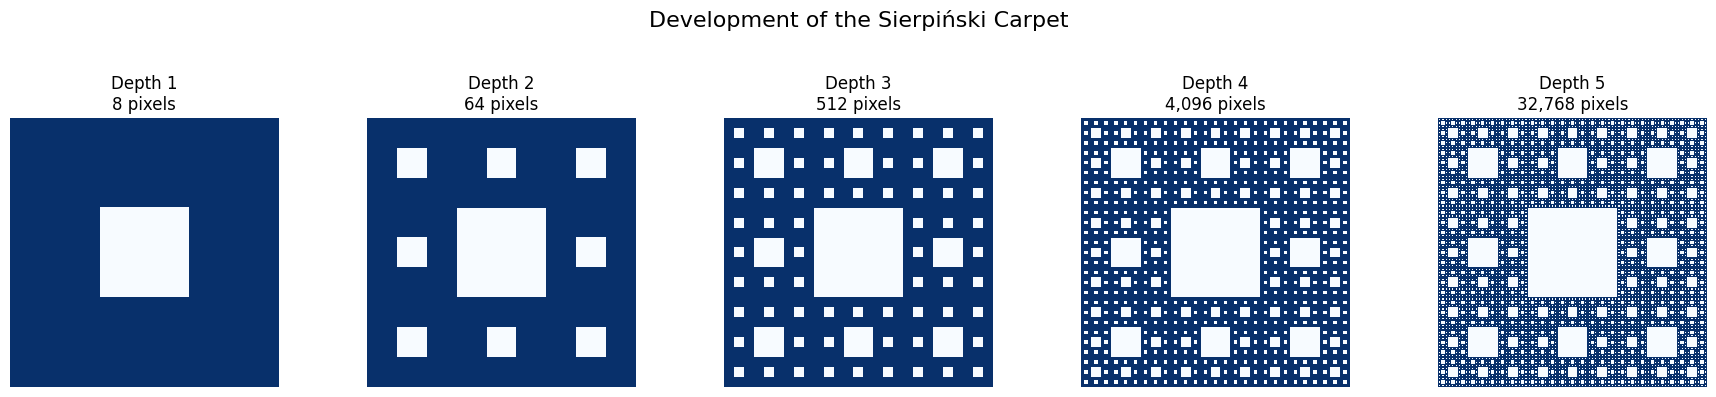

In [4]:
# 比较不同递归深度下 Sierpiński Carpet 的变化
# Compare the Sierpiński Carpet at different recursion depths

comparison_depths = [1, 2, 3, 4, 5]

# 创建一行五张子图
# Create one row containing five subplots
fig, axes = plt.subplots(
    1,
    len(comparison_depths),
    figsize=(18, 4)
)

for axis, current_depth in zip(axes, comparison_depths):

    # 在 GPU 上生成当前深度的 Sierpiński Carpet
    # Generate the carpet at the current depth on the GPU
    current_carpet = generate_sierpinski_carpet(
        current_depth,
        device
    )

    # 计算实际保留的像素数量
    # Count the actual number of remaining pixels
    current_pixels = int(current_carpet.sum().item())

    # 理论上，深度 d 应该保留 8^d 个像素
    # Theoretically, depth d should contain 8^d occupied pixels
    expected_pixels = 8 ** current_depth

    # 检查实际结果是否等于理论结果
    # Check whether the actual result matches the theoretical result
    assert current_pixels == expected_pixels

    # 将张量移回 CPU，以便 Matplotlib 绘图
    # Move the tensor to the CPU for Matplotlib
    current_image = current_carpet.cpu().numpy()

    axis.imshow(
        current_image,
        cmap="Blues",
        origin="upper",
        interpolation="nearest"
    )

    # 标题显示递归深度和保留像素数量
    # Display the recursion depth and occupied pixel count
    axis.set_title(
        f"Depth {current_depth}\n"
        f"{current_pixels:,} pixels"
    )

    axis.axis("off")

# 添加整张比较图的标题，并预留顶部空间
# Add the main title and reserve enough space at the top
fig.suptitle(
    "Development of the Sierpiński Carpet",
    fontsize=16,
    y=0.98
)

plt.tight_layout(
    rect=[0, 0, 1, 0.86]
)

plt.show()

## Coordinate-Based Colour Visualisations

The binary image only shows whether each pixel is retained or removed. In this section, colour is used to display additional spatial information.

The first visualisation assigns colour according to the horizontal x-coordinate. The second assigns colour according to the vertical y-coordinate.

The fractal structure remains unchanged, but the colour gradients make the spatial arrangement of the retained pixels easier to interpret.

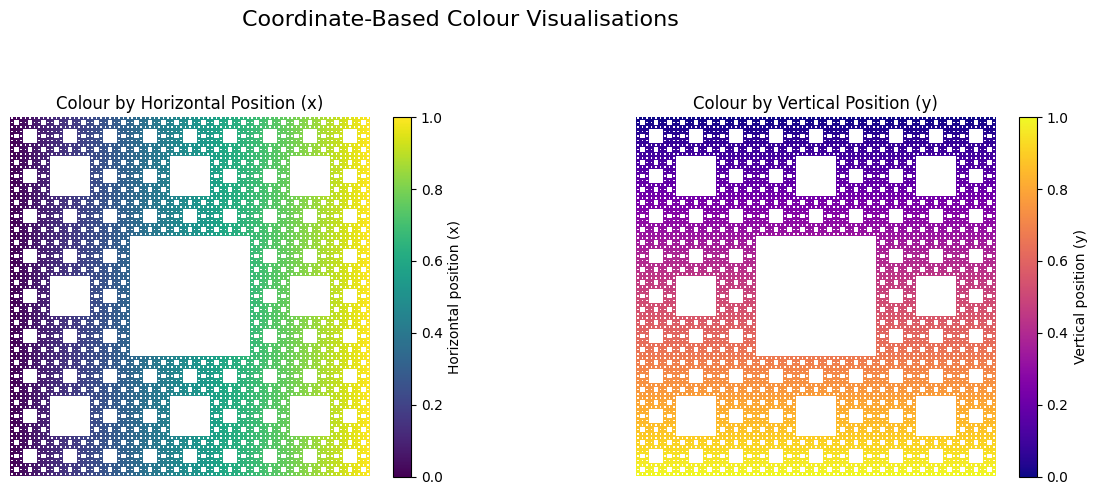

Colour visualisation depth: 5
Image size: (243, 243)
Occupied pixels: 32768
Tensor device: cuda:0


In [5]:
# 使用坐标信息创建两种颜色可视化
# Create two colour visualisations using coordinate information

colour_depth = 5

# 在 GPU 上生成 Sierpiński Carpet
# Generate the Sierpiński Carpet on the GPU
colour_carpet = generate_sierpinski_carpet(
    colour_depth,
    device
)

image_size = colour_carpet.shape[0]

# 创建从 0 到 1 的标准化坐标
# Create normalised coordinates ranging from 0 to 1
normalised_coordinates = torch.linspace(
    0.0,
    1.0,
    image_size,
    device=device
)

colour_y, colour_x = torch.meshgrid(
    normalised_coordinates,
    normalised_coordinates,
    indexing="ij"
)

# 为删除的像素设置 NaN，使中央空白区域不显示颜色
# Use NaN for removed pixels so that empty regions remain blank
empty_pixels = torch.full_like(
    colour_x,
    float("nan")
)

# 第一种颜色由横坐标 x 决定
# The first colour value is determined by horizontal position x
horizontal_colours = torch.where(
    colour_carpet,
    colour_x,
    empty_pixels
)

# 第二种颜色由纵坐标 y 决定
# The second colour value is determined by vertical position y
vertical_colours = torch.where(
    colour_carpet,
    colour_y,
    empty_pixels
)

# 将结果移回 CPU，供 Matplotlib 绘图
# Move the results to the CPU for Matplotlib
horizontal_image = horizontal_colours.cpu().numpy()
vertical_image = vertical_colours.cpu().numpy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

# 横坐标颜色图
# Horizontal-coordinate colour map
horizontal_plot = axes[0].imshow(
    horizontal_image,
    cmap="viridis",
    origin="upper",
    interpolation="nearest"
)

axes[0].set_title("Colour by Horizontal Position (x)")
axes[0].axis("off")

horizontal_colourbar = fig.colorbar(
    horizontal_plot,
    ax=axes[0],
    fraction=0.046,
    pad=0.04
)

horizontal_colourbar.set_label(
    "Horizontal position (x)"
)

# 纵坐标颜色图
# Vertical-coordinate colour map
vertical_plot = axes[1].imshow(
    vertical_image,
    cmap="plasma",
    origin="upper",
    interpolation="nearest"
)

axes[1].set_title("Colour by Vertical Position (y)")
axes[1].axis("off")

vertical_colourbar = fig.colorbar(
    vertical_plot,
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)

vertical_colourbar.set_label(
    "Vertical position (y)"
)

# 添加整张图的标题
# Add a title for the complete visualisation
fig.suptitle(
    "Coordinate-Based Colour Visualisations",
    fontsize=16,
    y=0.98
)

plt.tight_layout(
    rect=[0, 0, 1, 0.91]
)

plt.show()

print("Colour visualisation depth:", colour_depth)
print("Image size:", tuple(colour_carpet.shape))
print("Occupied pixels:", int(colour_carpet.sum().item()))
print("Tensor device:", colour_carpet.device)